# Day 4 — t-SNE & Anomaly Detection

Visualizing the Breast Cancer Wisconsin dataset with t-SNE, comparing it to the PCA projection from Day 3, and detecting anomalies with Isolation Forest.

## Loading and Preparing the Dataset
Load the dataset, separate features and target, and check the class distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)
print("Columns:" , df.columns.tolist())

df.head()

Dataset shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:

X = df.drop(["diagnosis", "id", "Unnamed: 32"] , axis =1)
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("Target distribution:" , y.value_counts())


Features shape: (569, 30)
Target shape: (569,)
Target distribution: diagnosis
B    357
M    212
Name: count, dtype: int64


The dataset contains 569 observations and 33 columns. After removing the patient id and the empty Unnamed: 32 column, 30 numeric features remain.

The diagnosis column is kept as the target label for interpretation only. The anomaly detection process below is fully unsupervised and does not use the diagnosis labels during training.

The dataset contains 357 benign (B) and 212 malignant (M) observations.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (569, 30)
Scaled shape: (569, 30)


The 30 numerical features are standardized using StandardScaler so that features with larger numerical ranges do not dominate the analysis.

The standardized dataset retains the same 569 × 30 shape and is used as input for both PCA and t-SNE.

## Recreating the Day 3 PCA Projection

Refit PCA using all components to examine the cumulative explained variance, then reduce the standardized data to 10 principal components. The first 10 components retain approximately 95.16% of the total variance and are used as the feature representation for Isolation Forest.

In [4]:
pca = PCA()

X_pca_full = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Total components:", X_pca_full.shape[1])
print("Variance explained by first 2 components:", cumulative_variance[1])
print("Variance explained by first 10 components:",cumulative_variance[9])

Total components: 30
Variance explained by first 2 components: 0.6324320765155944
Variance explained by first 10 components: 0.9515688143366668


The first two principal components explain approximately 63.24% of the total variance, while the first 10 components explain approximately 95.16%.

This confirms that the first 10 components provide a substantial reduction from the original 30 features while preserving most of the information in the dataset.

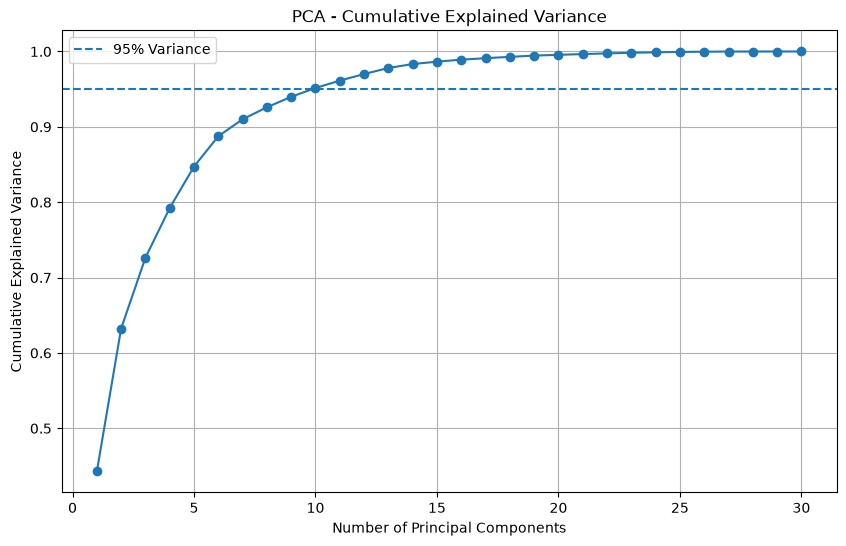

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.axhline(y=0.95, linestyle="--", label="95% Variance")
plt.legend()
plt.grid(True)
plt.show()

The cumulative explained variance plot shows that the 95% variance threshold is reached at approximately the 10th principal component. Therefore, 10 components are selected for the subsequent anomaly detection analysis.

In [6]:
pca_10 = PCA(n_components=10, random_state=42)

X_pca = pca_10.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("PCA features:", X_pca.shape[1])
print("Explained variance:", pca_10.explained_variance_ratio_.sum())

Original features: 30
PCA features: 10
Explained variance: 0.9515688143366667


The 30 original features are reduced to 10 principal components while retaining approximately 95.16% of the total variance.

This reduced representation is used as the input to Isolation Forest, allowing anomaly detection to operate on a lower-dimensional representation while preserving most of the original information.

## Step 3 — Running Isolation Forest

Isolation Forest is used as an unsupervised anomaly detection method. The model is fitted on the 10 PCA components without using the diagnosis labels.

A contamination value of 0.05 is used, meaning that approximately 5% of the observations are expected to be anomalies.

In [7]:
iso_pipeline = Pipeline([
    ("isolation_forest", IsolationForest(
        contamination=0.05,
        random_state=42
    ))
])

iso_pipeline.fit(X_pca)

preds = iso_pipeline.predict(X_pca)

print("Total samples:", len(preds))
print("Normal samples:", np.sum(preds == 1))
print("Anomalies:", np.sum(preds == -1))

Total samples: 569
Normal samples: 540
Anomalies: 29


Isolation Forest flagged 29 observations as anomalies and classified 540 observations as normal.

The 29 anomalies represent approximately 5.1% of the dataset, which is consistent with the selected contamination value of 0.05.

In [8]:
anomaly_mask = preds == -1
normal_mask = preds == 1

print("Anomaly count:", anomaly_mask.sum())
print("Normal count:", normal_mask.sum())

anomalies = df.loc[anomaly_mask].copy()

print("\nAnomalies by diagnosis:")
print(anomalies["diagnosis"].value_counts())

anomalies.head(10)

Anomaly count: 29
Normal count: 540

Anomalies by diagnosis:
diagnosis
M    15
B    14
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.71190,0.26540,0.4601,0.11890,NaN
3,84348301,M,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.68690,0.25750,0.6638,0.17300,NaN
9,84501001,M,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.18530,1.05800,1.10500,0.22100,0.4366,0.20750,NaN
12,846226,M,19.170,24.80,132.40,1123.0,0.09740,0.24580,0.20650,0.11180,...,29.94,151.70,1332.0,0.10370,0.39030,0.36390,0.17670,0.3176,0.10230,NaN
25,852631,M,17.140,16.40,116.00,912.7,0.11860,0.22760,0.22290,0.14010,...,21.40,152.40,1461.0,0.15450,0.39490,0.38530,0.25500,0.4066,0.10590,NaN
38,855133,M,14.990,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,...,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,0.1565,0.05504,NaN
42,855625,M,19.070,24.81,128.30,1104.0,0.09081,0.21900,0.21070,0.09961,...,33.17,177.40,1651.0,0.12470,0.74440,0.72420,0.24930,0.4670,0.10380,NaN
68,859471,B,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,...,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750,NaN
71,859711,B,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,...,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840,NaN
78,8610862,M,20.180,23.97,143.70,1245.0,0.12860,0.34540,0.37540,0.16040,...,31.72,170.30,1623.0,0.16390,0.61640,0.76810,0.25080,0.5440,0.09964,NaN


Among the 29 observations flagged as anomalies, 15 are malignant (M) and 14 are benign (B).

Although diagnosis was not used by Isolation Forest, the malignant observations are slightly over-represented among the detected anomalies. However, the nearly even split shows that anomaly detection does not directly correspond to the diagnosis label.

An anomaly represents an observation with an unusual feature pattern, regardless of whether its diagnosis is benign or malignant.

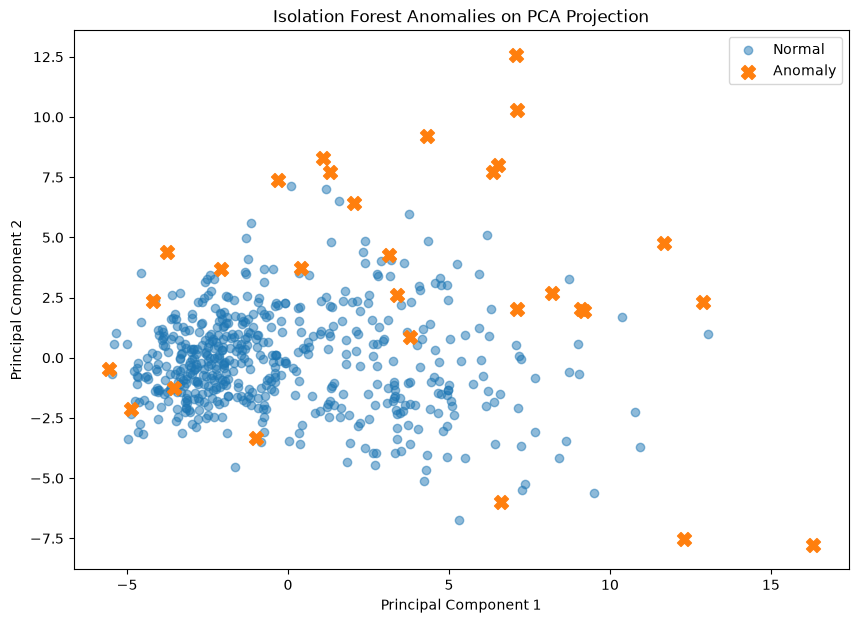

In [9]:
plt.figure(figsize=(10, 7))

normal_mask = preds == 1
anomaly_mask = preds == -1

plt.scatter(
    X_pca[normal_mask, 0],
    X_pca[normal_mask, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca[anomaly_mask, 0],
    X_pca[anomaly_mask, 1],
    marker="X",
    s=100,
    label="Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomalies on PCA Projection")
plt.legend()
plt.show()

### Visualizing Anomalies with PCA

The PCA projection shows that many of the observations classified as anomalies are located near the outer regions of the main data distribution.

However, some anomalies are located relatively close to normal observations. This is expected because Isolation Forest was trained using the 10-dimensional PCA representation, while the visualization displays only the first two principal components.

Therefore, the 2D PCA plot provides a useful visual interpretation of the detected anomalies, but it does not fully represent the feature space used by the model.

##   t-SNE Visualization

t-SNE is applied to the standardized 30-dimensional feature space to create a two-dimensional representation that emphasizes local relationships between observations.

Unlike PCA, t-SNE is a nonlinear dimensionality reduction technique and its axes do not have a direct interpretation.

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=500,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("t-SNE shape:", X_tsne.shape)

Original shape: (569, 30)
t-SNE shape: (569, 2)


The t-SNE representation reduces the 30 standardized features to two dimensions while focusing on preserving local neighborhood relationships.

The resulting 2D representation is used only for visualization; Isolation Forest predictions were obtained independently from the PCA-based feature representation.

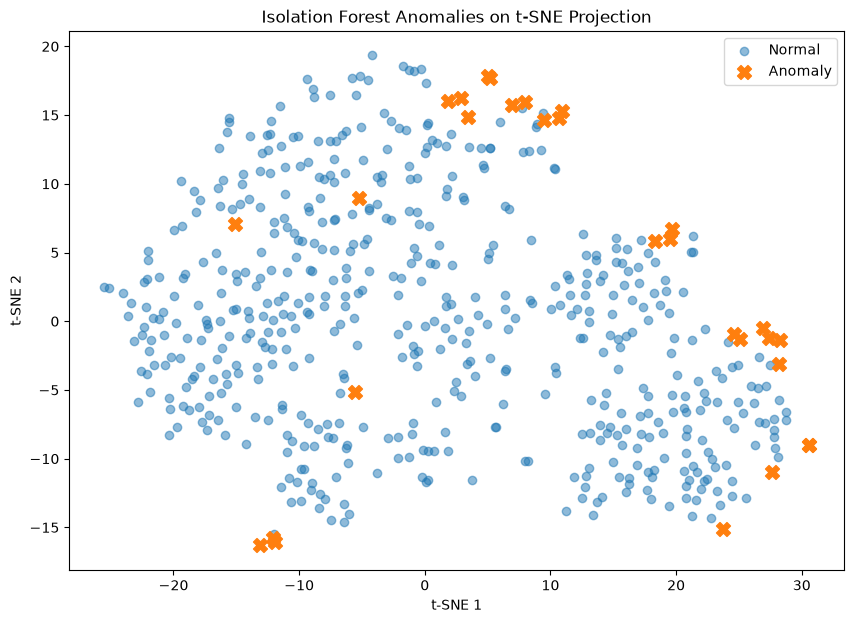

In [11]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[normal_mask, 0],
    X_tsne[normal_mask, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_tsne[anomaly_mask, 0],
    X_tsne[anomaly_mask, 1],
    marker="X",
    s=100,
    label="Anomaly"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Isolation Forest Anomalies on t-SNE Projection")
plt.legend()
plt.show()

### Visualizing Anomalies with t-SNE

The t-SNE projection provides a nonlinear representation of the original 30-dimensional feature space and focuses on preserving local relationships between observations.

The visualization helps examine how the observations classified as anomalies are distributed within the local structure of the dataset.

Unlike PCA, the axes of t-SNE do not represent specific directions of maximum variance. Therefore, the plot should mainly be interpreted in terms of local neighborhoods and relative grouping rather than the absolute values of the axes.

In [12]:
anomaly_scores = iso_pipeline.decision_function(X_pca)

results = df.copy()

results["anomaly_score"] = anomaly_scores
results["anomaly_prediction"] = preds

print(results["anomaly_prediction"].value_counts())


anomaly_prediction
 1    540
-1     29
Name: count, dtype: int64


Isolation Forest provides a continuous anomaly score for each observation using decision_function.

Lower scores indicate observations that are more anomalous, while higher scores indicate observations that are more consistent with the rest of the dataset.

## Inspecting the Most Anomalous Points

The observations are sorted by anomaly score to identify the points considered most unusual by Isolation Forest.

In [13]:
most_anomalous = results.sort_values(
    by="anomaly_score"
).head(10)

display(
    most_anomalous[
        ["diagnosis", "anomaly_score", "anomaly_prediction"]
    ]
)

,diagnosis,anomaly_score,anomaly_prediction
212,M,-0.234376,-1
152,B,-0.172168,-1
461,M,-0.167325,-1
213,M,-0.150789,-1
71,B,-0.131582,-1
192,B,-0.129541,-1
68,B,-0.127257,-1
3,M,-0.109635,-1
190,M,-0.103899,-1
78,M,-0.095389,-1


The most anomalous observations have the lowest anomaly scores. These observations are statistically unusual according to the feature patterns learned by Isolation Forest.

The diagnosis labels are shown only for interpretation and were not used during anomaly detection.

In [14]:
comparison = pd.crosstab(
    results["diagnosis"],
    results["anomaly_prediction"],
    normalize="index") * 100

print(comparison)

anomaly_prediction        -1          1
diagnosis                              
B                   3.921569  96.078431
M                   7.075472  92.924528


The row-normalized comparison shows that approximately 3.92% of benign observations and 7.08% of malignant observations were flagged as anomalies.

This indicates that malignant observations were more frequently identified as unusual by Isolation Forest. However, the difference does not mean that the model is detecting malignancy, since the diagnosis labels were not used during training.

(Same cross-tab recomputed — confirms the 3.92% / 7.08% split above.)

In [15]:
y_binary = (y == "M").astype(int)
anomaly_binary = (preds == -1).astype(int)

cm = confusion_matrix(y_binary, anomaly_binary)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[343  14]
 [197  15]]


The confusion matrix is included only as an exploratory comparison between the known diagnosis labels and the unsupervised anomaly predictions.

It should not be interpreted as a classification performance evaluation. Isolation Forest was not trained to predict benign or malignant diagnosis; it was trained only to identify statistically unusual observations.

## Final Summary

In [17]:

print("Total samples:", len(X))
print("Original features:", X.shape[1])
print("PCA components:", X_pca.shape[1])
print("PCA variance retained:", round(
    pca_10.explained_variance_ratio_.sum() * 100, 2
), "%")
print("Normal samples:", np.sum(preds == 1))
print("Anomalies:", np.sum(preds == -1))
print("t-SNE dimensions:", X_tsne.shape[1])

Total samples: 569
Original features: 30
PCA components: 10
PCA variance retained: 95.16 %
Normal samples: 540
Anomalies: 29
t-SNE dimensions: 2


## Final Summary

**PCA:** The original 30 features were reduced to 10 principal components while retaining 95.16% of the total variance. PCA provides a useful global representation of the dataset and was used as the feature space for Isolation Forest.

**t-SNE:** t-SNE reduced the 30 standardized features to two dimensions and provided a nonlinear visualization focused on local relationships between observations. Unlike PCA, its axes do not have a direct interpretation.

**Anomaly Detection:** Isolation Forest identified 29 out of 569 observations as anomalies, while 540 were classified as normal. Among the detected anomalies, 15 were malignant and 14 were benign. Since the diagnosis labels were not used during training, these results should be interpreted as unusual observations rather than predictions of malignancy.

**Key Takeaway:** PCA, t-SNE, and Isolation Forest serve different purposes. PCA summarizes global variance, t-SNE visualizes local structure, and Isolation Forest identifies observations with unusual patterns. Anomaly detection is therefore complementary to classification rather than a replacement for it.